# Claim 1 Evaluation and the Two Gates

Scores the trained model against the full baseline ladder on the 2024 frame, audits the
query machinery that produces those scores, and reports both pre-registered gates. Both
gates fail, and most of this notebook is the work of making that failure attributable
rather than merely recorded.

Every number is read from an artifact committed under `results/phase_e` or `results/phase_d`.
Nothing here trains, scores, or recomputes.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.analysis import claim1_eval
from src.model import query

## Configuration

Artifact locations and the orderings used for every table below. The scored arm is the
`d10_baseline` ensemble and the frame is 2024, which is the selection season rather than the
test season.

In [2]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)

PHASE_E_DIR = REPO_ROOT / "results/phase_e"
PHASE_C_DIR = REPO_ROOT / "results/phase_c"
PHASE_D_DIR = REPO_ROOT / "results/phase_d"

SCORED_ARM = "e11_d10_baseline"
EVAL_SEASON = 2024

LADDER_ORDER = ["no_info_league_average", "c1_raw", "c1_bucketed", "c2_bivariate",
                "c2_book_rho_reference", "c3_gbm_outcome", "c3_gbm_full", "phase_d"]
STRATUM_ORDER = ["low", "medium", "high", "all"]


def load_e(name):
    """Read one committed Phase E artifact by filename."""
    return pd.read_csv(PHASE_E_DIR / name)


def load_json_e(name):
    """Read one committed Phase E JSON artifact by filename."""
    return json.loads((PHASE_E_DIR / name).read_text())

## Run parameters read from their owner modules

The eval frame thresholds and the query machinery defaults are imported, so a moved constant
breaks this cell rather than quietly disagreeing with the artifacts.

In [3]:
pd.Series({
    "eval season": EVAL_SEASON,
    "stabilization anchor, PA": claim1_eval.STABILIZATION_N_STAR,
    "stratum boundaries in prior PA": str(claim1_eval.STRATUM_BOUNDARIES),
    "eval season PA floor": claim1_eval.MIN_EVAL_PA,
    "committed censoring sweep": str(claim1_eval.MIN_EVAL_PA_SENSITIVITY),
    "count states in the chain": len(query.COUNT_STATES),
    "absorbing states": str(query.ABSORBING_KEYS),
    "pitches drawn per count cell": query.DEFAULT_N_PITCHES,
}, name="value").to_frame()

,value
eval season,2024
"stabilization anchor, PA",226
stratum boundaries in prior PA,"(113, 452)"
eval season PA floor,10
committed censoring sweep,"(10, 25, 50)"
count states in the chain,12
absorbing states,"('bb', 'k', 'hbp', 'bip')"
pitches drawn per count cell,6


## The two gates as pre-registered

No numeric threshold was set in advance. An ordering claim holds only if the model beats
both C.2 and C.3 full on weighted rank correlation in the stratum claimed, by paired
difference with batter clustering and a 95 percent interval excluding zero. The RMSE gate is
set against C.3 full alone.

The platoon adoption rule is separate and stricter. It asks whether the model beats the
incumbent at predicting the platoon differential itself, not the two sides.

## Eval frame coverage

How many batter by hand rows survive the eval season PA floor, and what the filter removes.
Dropped rows have a markedly lower wOBA than scored rows in every stratum, which is why the
floor is swept rather than fixed.

In [4]:
report = load_json_e("e_report.json")
coverage = report["e4_calibration"]["coverage"]
for key, value in coverage.items():
    if key != "by_stratum":
        print(f"{key}: {value}")

eval_season: 2024
actual_groups: 1279
dropped_below_min_eval_pa: 130
min_eval_pa: 10
dropped_no_prediction: 0
scored_groups: 1149


In [5]:
stratum_coverage = pd.DataFrame(coverage["by_stratum"]).T
stratum_coverage = stratum_coverage.loc[
    [s for s in STRATUM_ORDER if s in stratum_coverage.index]]
stratum_coverage.round(4)

,scored,dropped,share_dropped,mean_woba_scored,mean_woba_dropped
low,380.0,85.0,0.1828,0.2715,0.1979
medium,280.0,33.0,0.1054,0.2862,0.2245
high,489.0,12.0,0.0240,0.3042,0.1730


## The full ladder on the claim 1 metric

Every baseline rung plus the model, scored on the same frame against the same answer key.
RMSE is PA weighted and lower is better. No comparison is claimed from these absolute
numbers, because two models scored against the same noisy target cannot be separated that
way.

In [6]:
ladder = load_e(f"d5_claim1_scores_{SCORED_ARM}.csv")
ladder["model"] = pd.Categorical(ladder["model"], LADDER_ORDER, ordered=True)
ladder["stratum"] = pd.Categorical(ladder["stratum"], STRATUM_ORDER, ordered=True)
ladder.pivot_table(index="model", columns="stratum",
                   values="pa_weighted_rmse", observed=False).round(5)

/var/folders/pf/jgfmjd9j39z8dmn0hk1cgswh0000gn/T/ipykernel_18777/551841051.py:2: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  ladder["model"] = pd.Categorical(ladder["model"], LADDER_ORDER, ordered=True)


stratum,low,medium,high,all
model,,,,
no_info_league_average,0.06310,0.05142,0.04795,0.05171
c1_raw,0.10542,0.06380,0.04312,0.06316
c1_bucketed,0.06598,0.05852,0.04315,0.05131
c2_bivariate,0.06176,0.05062,0.04105,0.04743
c2_book_rho_reference,0.06198,0.05017,0.04100,0.04736
c3_gbm_outcome,0.05943,0.05021,0.04096,0.04676
c3_gbm_full,0.05868,0.04949,0.04081,0.04634


## Skill against the no information reference

The same errors expressed as the share of between hitter talent variance each rung captures.
Negative means worse than predicting the league average for everybody.

In [7]:
ladder.pivot_table(index="model", columns="stratum",
                   values="skill_vs_no_info", observed=False).round(4)

stratum,low,medium,high,all
model,,,,
no_info_league_average,0.0000,0.0000,0.0000,0.0000
c1_raw,-5.1833,-1.7432,0.3709,-1.1485
c1_bucketed,-0.2706,-0.9539,0.3689,0.0365
c2_bivariate,0.1216,0.0993,0.5182,0.3706
c2_book_rho_reference,0.1016,0.1544,0.5216,0.3764
c3_gbm_outcome,0.3268,0.1497,0.5241,0.4265
c3_gbm_full,0.3911,0.2375,0.5349,0.4602


## Rank correlation by rung and stratum

The ordering metric, weighted by the wOBA denominator. This is the column the ordering gate
is decided on.

In [8]:
ladder.pivot_table(index="model", columns="stratum",
                   values="rank_corr_weighted", observed=False).round(4)

stratum,low,medium,high,all
model,,,,
no_info_league_average,-0.0730,0.0508,0.1071,0.0151
c1_raw,0.0416,0.1223,0.4899,0.3493
c1_bucketed,-0.0594,0.1431,0.4896,0.3604
c2_bivariate,0.1389,0.1926,0.5089,0.4103
c2_book_rho_reference,0.1260,0.2016,0.5066,0.4096
c3_gbm_outcome,0.0846,0.1811,0.4955,0.4041
c3_gbm_full,0.1665,0.2615,0.5238,0.4417


## The same ladder against a second answer key

Everything above is scored against observed wOBA, which carries the batted ball luck the
model is not trying to predict. Rescoring against xwOBA asks whether the ranking survives an
answer key with less of that luck in it. The model's ordering advantage is larger here and
its level error is larger, which is the same level versus order split the paired gates
handle.

In [ ]:
both_targets = load_e(f"d5_both_targets_{SCORED_ARM}.csv")
both_targets = both_targets[both_targets["stratum"] == "all"]
both_targets.pivot_table(index="model", columns="target",
                         values=["pa_weighted_rmse", "rank_corr_weighted"]).round(4)

## Noise floor share of squared error

The held out target is itself a small sample measurement, so errors add in quadrature and
every rung pays the same floor. In the low stratum the floor dominates, which is why real
differences compress into what reads as rounding.

In [9]:
floor = ladder[ladder["model"] == "no_info_league_average"].copy()
floor["floor_share_of_mse"] = floor["noise_floor"] ** 2 / floor["pa_weighted_rmse"] ** 2
floor.set_index("stratum")[["n_hitters", "pa_weighted_rmse", "noise_floor",
                            "model_rmse", "floor_share_of_mse"]].round(4)

,n_hitters,pa_weighted_rmse,noise_floor,model_rmse,floor_share_of_mse
stratum,,,,,
low,380,0.0631,0.0510,0.0371,0.6544
medium,280,0.0514,0.0427,0.0286,0.6903
high,489,0.0479,0.0334,0.0344,0.4848
all,1149,0.0517,0.0391,0.0338,0.5720


## The gate verdicts

The model against each of the two named opponents, paired and batter clustered. Positive
rank difference favours the model. A gate passes only when the interval excludes zero.

In [10]:
gates = load_e(f"d5_claim1_paired_{SCORED_ARM}.csv")
gates["stratum"] = pd.Categorical(gates["stratum"], STRATUM_ORDER, ordered=True)
gates.sort_values(["opponent", "stratum"])[
    ["opponent", "stratum", "n_hitters", "n_batters",
     "rank_a", "rank_b", "rank_difference", "ci_low_rank", "ci_high_rank",
     "rmse_difference", "ci_low_rmse", "ci_high_rmse"]].round(5).reset_index(drop=True)

,opponent,stratum,n_hitters,n_batters,rank_a,rank_b,rank_difference,ci_low_rank,ci_high_rank,rmse_difference,ci_low_rmse,ci_high_rmse
0,c2_bivariate,low,380,239,0.25924,0.13888,0.12036,-0.02382,0.26310,-0.00253,-0.00484,-0.00025
1,c2_bivariate,medium,280,238,0.33888,0.19264,0.14624,-0.00532,0.28358,-0.00140,-0.00424,0.00194
2,c2_bivariate,high,489,318,0.48909,0.50889,-0.01980,-0.08793,0.04460,0.00253,0.00072,0.00426
3,c2_bivariate,all,1149,604,0.45910,0.41028,0.04882,-0.00891,0.10504,0.00050,-0.00088,0.00186
4,c3_gbm_full,low,380,239,0.25924,0.16650,0.09274,-0.03429,0.21941,0.00055,-0.00134,0.00249
5,c3_gbm_full,medium,280,238,0.33888,0.26153,0.07735,-0.02146,0.18008,-0.00027,-0.00242,0.00206
6,c3_gbm_full,high,489,318,0.48909,0.52384,-0.03476,-0.09184,0.01937,0.00277,0.00128,0.00433
7,c3_gbm_full,all,1149,604,0.45910,0.44175,0.01735,-0.02368,0.05881,0.00159,0.00054,0.00271


In [11]:
verdict = load_json_e(f"d5_claim1_verdict_{SCORED_ARM}.json")
print(json.dumps(verdict, indent=2)[:1200])

{
  "decisive_stratum": "low",
  "rmse_gate_vs_c3_full": false,
  "ordering_gate_vs_both": false,
  "by_stratum": {
    "all": {
      "rmse_gate_vs_c3_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "high": {
      "rmse_gate_vs_c3_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "low": {
      "rmse_gate_vs_c3_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "medium": {
      "rmse_gate_vs_c3_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    }
  },
  "debiased_mean_excess_removed": 0.014328411015594357,
  "debiased_rmse_difference": {
    "low": {
      "rmse_difference": -0.00028003822323550975,
      "ci_low": -0.0026505727077412427,
      "ci_high": 0.0020008958292344124
    },
    "medium": {
      "rmse_difference": -0.0020925782845069435,
      "ci_low": -0.004705494457377533,
      "ci_high": 0.00045465548658734636
    },
    "hig

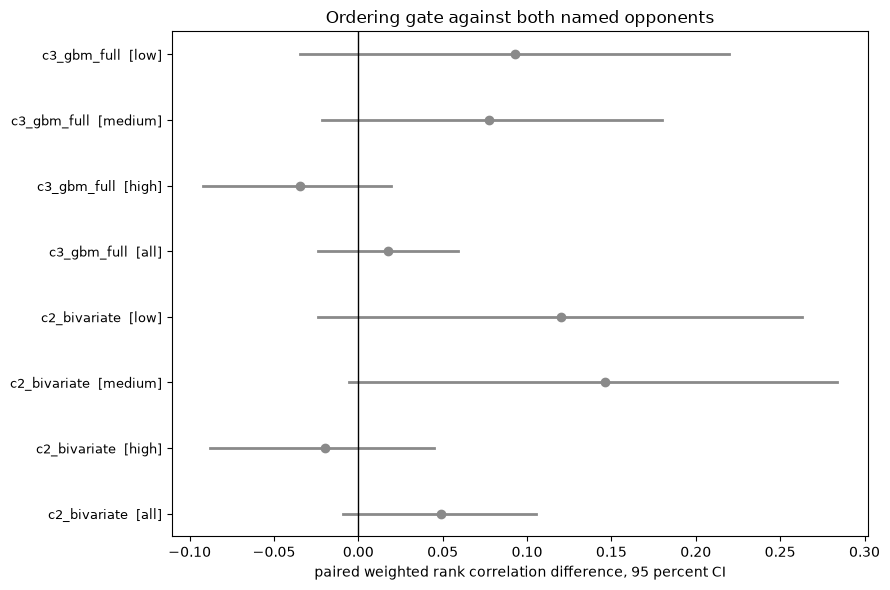

In [12]:
PASS_COLOR = "#2d7f3e"
FAIL_COLOR = "#8a8a8a"

plotted = gates.sort_values(["opponent", "stratum"], ascending=[True, False]).reset_index(drop=True)
figure, axis = plt.subplots(figsize=(9, 6))
for position, row in plotted.iterrows():
    excludes_zero = row["ci_low_rank"] > 0
    color = PASS_COLOR if excludes_zero else FAIL_COLOR
    axis.plot([row["ci_low_rank"], row["ci_high_rank"]], [position, position], color=color, lw=2)
    axis.plot(row["rank_difference"], position, "o", color=color, ms=6)
axis.axvline(0, color="black", lw=1)
axis.set_yticks(range(len(plotted)))
axis.set_yticklabels([f"{row.opponent}  [{row.stratum}]" for row in plotted.itertuples()],
                     fontsize=9)
axis.set_xlabel("paired weighted rank correlation difference, 95 percent CI")
axis.set_title("Ordering gate against both named opponents")
figure.tight_layout()
plt.show()

## Why the low stratum result is underpowered rather than absent

The model leads C.3 full on weighted rank in the low stratum by a margin larger than most
published effects, and the interval still spans zero. This restates the gap as the number of
batters that would be needed to resolve it.

In [13]:
power = load_e(f"d5_power_restatement_{SCORED_ARM}.csv")
power.set_index("stratum").round(4)

,n_batters,rank_difference,se_rank,z,batters_multiplier,batters_needed
stratum,,,,,,
low,239,0.0927,0.0647,1.4329,3.8226,914
medium,238,0.0773,0.0514,1.5044,3.4682,825
high,318,-0.0348,0.0284,-1.2250,5.2300,1663
all,604,0.0174,0.0210,0.8247,11.5408,6971


## Noise floor deconvolution

The same head to head with the target noise removed from both sides, so the comparison is
between the models rather than between two measurements of a noisy answer key.

In [14]:
debiased = load_e(f"d5_claim1_debiased_{SCORED_ARM}.csv")
debiased["stratum"] = pd.Categorical(debiased["stratum"], STRATUM_ORDER, ordered=True)
debiased.sort_values(["opponent", "stratum"]).round(5).reset_index(drop=True)

,opponent,stratum,n_hitters,n_batters,rmse_a,rmse_b,rmse_difference,ci_low,ci_high,favours_a_share
0,c3_gbm_full,low,380,239,0.05840,0.05868,-0.00028,-0.00265,0.00200,0.5945
1,c3_gbm_full,medium,280,238,0.04740,0.04949,-0.00209,-0.00471,0.00045,0.9430
2,c3_gbm_full,high,489,318,0.04064,0.04081,-0.00016,-0.00175,0.00134,0.5880
3,c3_gbm_full,all,1149,604,0.04574,0.04634,-0.00060,-0.00174,0.00059,0.8445


In [15]:
achievable = load_e(f"d5_achievable_floor_{SCORED_ARM}.csv")
achievable.set_index("stratum").round(5)

,n_hitters,achievable_floor,xwoba_bias
stratum,,,
low,380,0.03640,0.00351
medium,280,0.03309,0.00407
high,489,0.02521,0.00634
all,1149,0.02923,0.00536


## The verdict across the censoring sweep

Every headline is reported across a three times swing in how much of the eval population the
PA floor removes. The verdict does not depend on the filter, and in the low stratum the gap
grows as the floor rises.

In [16]:
sweep = load_e("e11b_min_pa_sweep.csv")
sweep["stratum"] = pd.Categorical(sweep["stratum"], STRATUM_ORDER, ordered=True)
sweep.sort_values(["opponent", "stratum", "min_eval_pa"])[
    ["min_eval_pa", "opponent", "stratum", "n_hitters", "n_batters",
     "rank_difference", "ci_low_rank", "ci_high_rank",
     "rmse_favours_phase_d", "rank_favours_phase_d"]].round(5).reset_index(drop=True)

,min_eval_pa,opponent,stratum,n_hitters,n_batters,rank_difference,ci_low_rank,ci_high_rank,rmse_favours_phase_d,rank_favours_phase_d
0,10,c2_bivariate,low,380,239,0.12036,-0.02382,0.26310,True,False
1,25,c2_bivariate,low,294,204,0.11763,-0.02877,0.26061,True,False
2,50,c2_bivariate,low,194,141,0.15106,-0.01341,0.31508,False,False
3,10,c2_bivariate,medium,280,238,0.14624,-0.00532,0.28358,False,False
4,25,c2_bivariate,medium,250,218,0.14669,-0.00553,0.29276,False,False
5,50,c2_bivariate,medium,210,183,0.15450,0.00303,0.31023,False,True
6,10,c2_bivariate,high,489,318,-0.01980,-0.08793,0.04460,False,False
7,25,c2_bivariate,high,469,309,-0.02088,-0.09022,0.04440,False,False
8,50,c2_bivariate,high,444,300,-0.02006,-0.08781,0.04799,False,False
9,10,c2_bivariate,all,1149,604,0.04882,-0.00891,0.10504,False,False


## Composition fidelity on a matched population

The composed rates are compared against the population they actually score, using the same
trained hitter set and the same PA weights. The unmatched comparison averaged the model over
hitters holding a trained embedding row and the observation over every plate appearance, and
selection into having a row is selection on exposure.

In [17]:
matched = load_e("e1_matched_population.csv")
matched.round(5)

,window,population,n_pa,n_groups,bb,k,hbp,bip
0,train,pooled_all,1526308.0,NaN,0.08042,0.22338,0.01049,0.68571
1,train,matched,770182.0,1069.0,0.08312,0.23066,0.01153,0.67469
2,eval,pooled_all,181388.0,NaN,0.07950,0.22712,0.01114,0.68224
3,eval,matched,169589.0,1074.0,0.07994,0.22488,0.01127,0.68391


In [18]:
fidelity = pd.DataFrame(report["e1_matched_population"]).T
fidelity[["modelled", "eval_matched", "relative_error_vs_eval_matched",
          "pass_vs_eval_matched", "tolerance"]].round(5)

,modelled,eval_matched,relative_error_vs_eval_matched,pass_vs_eval_matched,tolerance
bb,0.085377,0.07994,0.068015,False,0.02
k,0.219644,0.224879,-0.023279,False,0.02
hbp,0.010882,0.011268,-0.034298,True,0.2
bip,0.684097,0.683912,0.00027,True,0.02


## Where the walk gap goes

The headline composition failure decomposed into owners. A population artifact, a structural
property of the count chain measured without the model at all, the pitch resampler, and a
remainder that no step claims.

In [19]:
structure = load_json_e("e10_structure_summary.json")
for key, value in structure.items():
    print(f"{key}: {value}")

n_pa: 1501600
n_pitchers: 1705
observed_bb: 0.0811154768247203
pooled_chain_bb: 0.08169570438963587
per_pitcher_chain_bb: 0.08228130735972017
structural_bb_bias_pooled: 0.0005802275649155753
structural_bb_bias_per_pitcher: 0.0011658305349998704
jensen_term_bb: 0.0005856029700842952
structural_bb_bias_relative: 0.014372479588809828
residual_walk_excess: 0.002259999999999998
share_of_residual_explained: 0.5158542190264918
structural_k_bias_relative: 0.004419014927336651


In [20]:
resampler = load_json_e("e7_resampler_summary.json")
take_mass = load_json_e("e9_take_mass_summary.json")
print(f"resampler channel one, surface: {take_mass['delta_bb_channel_1_surface']:.6f}")
print(f"resampler channel two, take mass: {take_mass['delta_bb_channel_2_take_mass']:.6f}")
print(f"resampler both channels: {take_mass['delta_bb_both_channels']:.6f}")
print(f"residual walk excess: {take_mass['residual_walk_excess']:.6f}")

resampler channel one, surface: 0.000932
resampler channel two, take mass: -0.000960
resampler both channels: -0.000028
residual walk excess: 0.002260


## The swing head is not the owner

The head was the standing suspect for the walk gap. Scored on held out real pitches it comes
in with the wrong sign in the three ball counts that would have to carry the effect.

In [21]:
swing = load_json_e("e6_swing_summary.json")
for key, value in swing.items():
    print(f"{key}: {value}")

arm: d10_baseline
seeds: [0, 1, 2, 3, 4]
eval_season: 2024
n_pitches: 705344
overall_observed: 0.4779752858179839
overall_predicted: 0.47925575717386953
overall_relative_gap: 0.0026789488784850508
three_ball_observed: 0.5927032661570535
three_ball_predicted: 0.6040052480569663
three_ball_relative_gap: 0.019068533185572223
under_three_ball_relative_gap: 0.000833706937429568
max_abs_count_relative_gap: 0.08739834697711174


## Composition rate errors by absorbing state

The four absorbing rates and the model against observed relative error, for the pooled chain
and the per pitcher chain. The strikeout row is the one that fails without an owner.

In [22]:
structure_table = load_e("e10_structure.csv")
structure_table.round(5)

,aggregation,rate_bb,rate_k,rate_hbp,rate_bip,relerr_bb,relerr_k,relerr_hbp,relerr_bip
0,observed,0.08112,0.22184,0.01058,0.68647,0.00000,0.00000,0.00000,0.00000
1,pooled_chain,0.08170,0.22146,0.01064,0.68621,0.00715,-0.00171,0.00567,-0.00038
2,per_pitcher_chain,0.08228,0.22282,0.01056,0.68434,0.01437,0.00442,-0.00123,-0.00311


## Calibration slope by stratum

Whether a predicted wOBA of X corresponds to an observed wOBA of X. A slope below one means
predictions are spread wider than outcomes. This tracks exposure by design and is reported
unscored.

In [23]:
calibration = load_e("e4_calibration.csv")
calibration["stratum"] = pd.Categorical(calibration["stratum"], STRATUM_ORDER, ordered=True)
calibration.sort_values("stratum").set_index("stratum").round(4)

,n_hitters,pa,mean_pred,mean_obs,intercept,slope,slope_se,slope_z_vs_one
stratum,,,,,,,,
low,380,32781.0,0.3031,0.2925,0.1322,0.5289,0.0962,-4.8981
medium,280,36877.0,0.3156,0.3023,0.0928,0.6639,0.1066,-3.1527
high,489,111114.0,0.3344,0.3186,-0.0153,0.9984,0.0894,-0.0176
all,1149,180772.0,0.3249,0.3106,0.0372,0.8414,0.0585,-2.7107


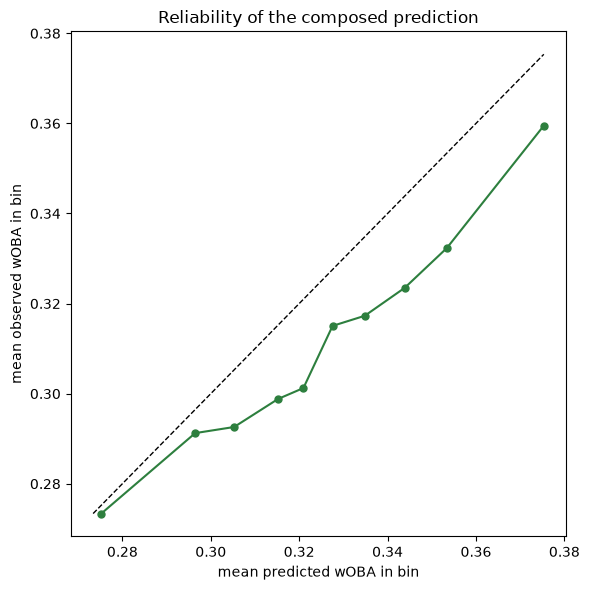

In [24]:
reliability = load_e("e4_reliability.csv")
figure, axis = plt.subplots(figsize=(6, 6))
axis.plot(reliability["mean_pred"], reliability["mean_obs"], "o-", color="#2d7f3e", ms=5)
limits = [min(reliability["mean_pred"].min(), reliability["mean_obs"].min()),
          max(reliability["mean_pred"].max(), reliability["mean_obs"].max())]
axis.plot(limits, limits, color="black", lw=1, ls="--")
axis.set_xlabel("mean predicted wOBA in bin")
axis.set_ylabel("mean observed wOBA in bin")
axis.set_title("Reliability of the composed prediction")
figure.tight_layout()
plt.show()

## Ensemble interval coverage

A separate honesty property from the calibration slope. It asks whether an X percent interval
covers X percent of outcomes. The seed only interval is the ensemble alone and the second
kind adds the target noise, which is the fair test.

In [25]:
coverage_json = load_json_e("e14_coverage.json")
print(f"mean seed sd: {coverage_json['mean_seed_sd']:.6f}")
print(f"mean target noise sd: {coverage_json['mean_target_noise_sd']:.6f}")
print(f"scored groups: {coverage_json['n_scored_groups']}")
print(f"pre registered expectation held: {coverage_json['expectation']['held']}")

mean seed sd: 0.004319
mean target noise sd: 0.053415
scored groups: 1149
pre registered expectation held: True


In [26]:
interval_coverage = load_e("e14_coverage.csv")
interval_coverage["slice"] = pd.Categorical(
    interval_coverage["slice"],
    [s for s in STRATUM_ORDER if s in set(interval_coverage["slice"])] +
    [s for s in interval_coverage["slice"].unique() if s not in STRATUM_ORDER],
    ordered=True)
interval_coverage.sort_values(["interval", "slice", "nominal"])[
    ["interval", "slice", "n_groups", "nominal", "empirical",
     "ci_low", "ci_high", "gap", "mean_half_width"]].round(4).reset_index(drop=True)

,interval,slice,n_groups,nominal,empirical,ci_low,ci_high,gap,mean_half_width
0,seed_only,low,380,0.50,0.0263,0.0144,0.0478,-0.4737,0.0032
1,seed_only,low,380,0.80,0.0553,0.0364,0.0830,-0.7447,0.0061
2,seed_only,low,380,0.95,0.0947,0.0692,0.1284,-0.8553,0.0093
3,seed_only,medium,280,0.50,0.0321,0.0170,0.0599,-0.4679,0.0030
4,seed_only,medium,280,0.80,0.0679,0.0439,0.1035,-0.7321,0.0057
5,seed_only,medium,280,0.95,0.0964,0.0671,0.1367,-0.8536,0.0087
6,seed_only,high,489,0.50,0.0348,0.0218,0.0550,-0.4652,0.0026
7,seed_only,high,489,0.80,0.0798,0.0589,0.1072,-0.7202,0.0050
8,seed_only,high,489,0.95,0.1166,0.0911,0.1480,-0.8334,0.0077
9,seed_only,all,1149,0.50,0.0313,0.0227,0.0431,-0.4687,0.0029


## The platoon adoption rule

The stricter claim, scored on the platoon differential itself rather than the two sides. No
stratum's paired interval excludes zero on rank, so the rule is not met on 2024.

In [27]:
platoon_scores = load_e("e5_platoon_scores.csv")
platoon_scores["stratum"] = pd.Categorical(platoon_scores["stratum"], STRATUM_ORDER, ordered=True)
platoon_scores.sort_values(["stratum", "model"]).round(5).reset_index(drop=True)

,stratum,model,n_hitters,weight,mean_obs,mean_pred,sd_obs,sd_pred,rmse,rank_corr_weighted
0,low,delta_pred,207,17065.80243,-0.00778,-0.00504,0.08445,0.02356,0.07851,0.39750
1,low,delta_route_a,207,17065.80243,-0.00778,-0.00372,0.08445,0.02068,0.07937,0.35389
2,medium,delta_pred,167,22500.03227,-0.00373,-0.00507,0.06511,0.02492,0.05836,0.38545
3,medium,delta_route_a,167,22500.03227,-0.00373,-0.00272,0.06511,0.02056,0.05972,0.41676
4,high,delta_pred,171,28207.93196,0.00852,-0.00039,0.05986,0.02302,0.05750,0.26247
5,high,delta_route_a,171,28207.93196,0.00852,-0.00045,0.05986,0.02008,0.05875,0.27002
6,all,delta_pred,545,67773.76666,0.00035,-0.00311,0.06871,0.02385,0.06371,0.34354
7,all,delta_route_a,545,67773.76666,0.00035,-0.00203,0.06871,0.02039,0.06486,0.34648


In [28]:
platoon_paired = load_e("e5_platoon_paired.csv")
platoon_paired["stratum"] = pd.Categorical(platoon_paired["stratum"], STRATUM_ORDER, ordered=True)
platoon_paired.sort_values("stratum").set_index("stratum").round(5)

,n_hitters,n_boot,rmse_difference,rmse_ci_low,rmse_ci_high,rmse_favours_model,rank_difference,rank_ci_low,rank_ci_high,rank_favours_model,rank_se
stratum,,,,,,,,,,,
low,207,2000,-0.00085,-0.00190,0.00022,False,0.04361,-0.03964,0.11852,False,0.04015
medium,167,2000,-0.00136,-0.00289,0.00010,False,-0.03131,-0.12621,0.05274,False,0.04562
high,171,2000,-0.00125,-0.00346,0.00095,False,-0.00755,-0.10500,0.08902,False,0.05014
all,545,2000,-0.00115,-0.00216,-0.00017,True,-0.00293,-0.05422,0.04961,False,0.02667


## The measurement ceiling on the platoon differential

Reliability is true talent variance over observed variance, and its square root is the
highest rank correlation any predictor could reach against this answer key. The ceiling is
low enough that the platoon result is partly a statement about the target.

In [29]:
ceiling = load_e("e15_ceiling_by_stand.csv")
ceiling.set_index("stand")[
    ["n_hitters", "tau_split_true", "mean_sampling_var_weighted",
     "reliability_variance_ratio", "reliability_mean_per_hitter",
     "ceiling_rank_corr"]].round(5)

,n_hitters,tau_split_true,mean_sampling_var_weighted,reliability_variance_ratio,reliability_mean_per_hitter,ceiling_rank_corr
stand,,,,,,
L,221,0.02706,0.00392,0.15732,0.14873,0.39663
R,324,0.02218,0.00419,0.10511,0.10245,0.32421
pooled,545,0.02430,0.00408,0.12644,0.12122,0.35559


## Between stand share of the predicted differential

The share of platoon differential variance that is the batter stand effect alone. The
observed share looks far below the model's until the sampling noise is removed from the
within stand term, and after correction the two agree. The uncorrected and corrected numbers
are the same errors in variables trap at two scales.

In [30]:
ceiling_json = load_json_e("e15_ceiling.json")
errors_in_variables = ceiling_json["part2_errors_in_variables"]
pd.Series({
    "observed variance raw": errors_in_variables["observed_variance_raw"],
    "between stand variance": errors_in_variables["between_stand_variance"],
    "within stand variance raw": errors_in_variables["within_stand_variance_raw"],
    "mean sampling variance weighted": errors_in_variables["mean_sampling_variance_weighted"],
    "within stand variance noise corrected": errors_in_variables["within_stand_variance_noise_corrected"],
    "share between stand uncorrected": errors_in_variables["share_between_stand_uncorrected"],
    "share between stand corrected": errors_in_variables["share_between_stand_corrected"],
    "corrected share CI low": errors_in_variables["ci_low"],
    "corrected share CI high": errors_in_variables["ci_high"],
    "noise share of observed variance": errors_in_variables["noise_share_of_observed_variance"],
}, name="value").to_frame().round(5)

,value
observed variance raw,0.00471
between stand variance,0.00051
within stand variance raw,0.00420
mean sampling variance weighted,0.00408
within stand variance noise corrected,0.00012
share between stand uncorrected,0.10898
share between stand corrected,0.81414
corrected share CI low,0.42175
corrected share CI high,3.49669
noise share of observed variance,0.86614


## Linear decodability of the platoon signal

A ridge probe on the frozen embeddings against the empirical Bayes posterior split. A linear
read out is deliberately weak, so this bounds what is linearly decodable rather than
demonstrating what the representation contains. The shuffled null is not centred on zero,
because out of fold predictions of noise are anti correlated with the target.

In [31]:
probe = load_json_e("e14_probe.json")["probe"]
print(f"hitters with a C.2 split: {probe['exclusions']['hitters_with_a_c2_split']}")
print(f"cold start excluded: {probe['exclusions']['cold_start_excluded']}")
print(f"hitters probed: {probe['exclusions']['hitters_probed']}")
print(f"embedding dimension: {probe['features']['embedding_dim']}")
print(f"seed handling: {probe['features']['seed_handling']}")

hitters with a C.2 split: 630
cold start excluded: 97
hitters probed: 533
embedding dimension: 32
seed handling: per-seed decode, correlations averaged; raw embeddings NEVER averaged


In [32]:
probe_results = probe.get("results", probe)
print(json.dumps(probe_results, indent=2)[:1400])

{
  "target": {
    "source_module": "src/analysis/c2_bivariate_eb.py::predict",
    "column": "pred_woba, pivoted on p_throws, split = L - R",
    "quantity": "C.2 empirical-Bayes POSTERIOR MEAN split (not the raw observed split)",
    "hyper_parameters_committed_at": "results/phase_c/c2_prior_parameters.csv"
  },
  "features": {
    "source": "results/checkpoints/d10_baseline_s{0..4}.pt, key model.embedding.weight",
    "vocabulary": "data/processed/phase_d5/manifest.json::vocabulary",
    "seed_handling": "per-seed decode, correlations averaged; raw embeddings NEVER averaged",
    "embedding_dim": 32
  },
  "exclusions": {
    "hitters_with_a_c2_split": 630,
    "cold_start_excluded": 97,
    "hitters_probed": 533
  },
  "cross_validation": "GroupKFold(5) on batter id, RidgeCV inside each fold",
  "by_stand": {
    "pooled": {
      "real": {
        "n_hitters": 533,
        "n_seeds": 5,
        "pearson": 0.1952975239726944,
        "pearson_ci_low": 0.12396639334135741,
        

## The balls in play value gap

The composed value of a ball in play against the observed value. The pre-registered
measurement seam explanation came in at the wrong sign, and era drift in the frozen value
table carries the gap instead, leaving a residual that absorbs the un orthogonalised
interaction.

In [33]:
bip_value = load_json_e("e13_bip_value.json")
pd.Series({
    "value modelled": bip_value["gap_being_explained"]["value_modelled_bip"],
    "value observed": bip_value["gap_being_explained"]["value_observed_bip"],
    "gap": bip_value["gap_being_explained"]["gap"],
    "check A share of gap": bip_value["check_a_measured_share_seam"]["share_of_gap"],
    "conditional drift": bip_value["check_b_era_drift"]["conditional_drift"],
    "conditional share of gap": bip_value["check_b_era_drift"]["conditional_share_of_gap"],
    "residual unexplained": bip_value["residual_unexplained"],
    "residual share of gap": bip_value["residual_share_of_gap"],
}, name="value").to_frame().round(6)

,value
value modelled,0.378642
value observed,0.363526
gap,0.015116
check A share of gap,-1.068685
conditional drift,0.028836
conditional share of gap,1.907627
residual unexplained,0.002435
residual share of gap,0.161057


## What this notebook establishes

- Both pre-registered gates fail in every stratum. The model does not beat the incumbent on
  the claim 1 metric on the 2024 frame.
- The low stratum ordering result is underpowered rather than absent. The model leads C.3
  full on weighted rank, and resolving that gap would need roughly four times the batters
  available.
- The verdict survives the committed censoring sweep at 10, 25, and 50 PA.
- The platoon adoption rule is not met. No stratum's paired interval excludes zero on rank.
- The walk gap is decomposed rather than carried. A population artifact and a structural
  property of the count chain own most of it, the swing head and the resampler are
  exonerated, and a remainder is recorded as open.
- Calibration tracks exposure as designed, and ensemble intervals under cover, which is a
  reported limitation rather than a rebuild.
- The platoon measurement ceiling is low, so part of the platoon result is a statement about
  the answer key rather than about the model.

Three constraints follow for whoever tunes the configuration next. Arms must not be selected
on the RMSE column alone, the unowned strikeout shortfall and the remainder of the walk gap
are still open, and any change to the ensemble width reopens the interval coverage
measurement above.